# 38 - Representation Alignment Unlearning (RAU)

Fine-tune the baseline model so its latent representation of forget samples
matches the retrain model's representation. The retrain model provides the
counterfactual: what these samples look like to a model that never memorized them.

Unlike parameter-space methods (blocked by Fisher overlap), RAU operates in
representation space. The loss is:

    L = ELBO(retain) + lambda * KL(student_posterior || retrain_posterior) on forget

Lambda sweep: {0.1, 1.0, 10.0, 100.0}

**Source:** `src/train_rau.py`

**Dependencies:** `outputs/p1/baseline/best_model.pt`, `outputs/p1/retrain_structured/best_model.pt`

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import torch
import json
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
from pathlib import Path

from utils import set_global_seed, GLOBAL_SEED, DEVICE
from vae import VAE
from train_rau import train_rau
from synthetic_utils import extract_mia_features, train_and_evaluate_attacker

set_global_seed(GLOBAL_SEED)
plt.style.use('seaborn-v0_8-whitegrid')

OUTPUT_DIR = Path('../outputs/rau')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Load data and models

In [2]:
adata = sc.read_h5ad('../data/adata_processed.h5ad')
X = adata.X.toarray() if hasattr(adata.X, 'toarray') else adata.X
leiden = adata.obs['leiden'].values

with open('../outputs/p1/split_structured.json') as f:
    split = json.load(f)
with open('../outputs/p1.5/s1_matched_negatives.json') as f:
    matched_data = json.load(f)

forget_idx = split['forget_indices']
retain_idx = split['retain_indices']
unseen_idx = split['unseen_indices']
matched_idx = matched_data['matched_indices']
c13_unseen = [i for i in unseen_idx if leiden[i] == '13']

X_forget = X[forget_idx]
X_retain = X[retain_idx]

def load_model(path):
    ckpt = torch.load(path, map_location=DEVICE)
    mc = {k: v for k, v in ckpt['config'].items()
          if k in ['input_dim', 'latent_dim', 'hidden_dims', 'likelihood', 'dropout', 'use_layer_norm']}
    model = VAE(**mc).to(DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    return model, ckpt['config']

baseline_model, config = load_model('../outputs/p1/baseline/best_model.pt')
retrain_model, _ = load_model('../outputs/p1/retrain_structured/best_model.pt')

## Lambda sweep

In [3]:
lambdas = [0.1, 1.0, 10.0, 100.0]
rau_models = {}
rau_histories = {}

for lam in lambdas:
    set_global_seed(GLOBAL_SEED)
    model, history = train_rau(
        baseline_model=baseline_model,
        retrain_model=retrain_model,
        X_forget=X_forget,
        X_retain=X_retain,
        lambda_align=lam,
        config=config,
        device=DEVICE,
        epochs=50,
        lr=1e-4,
        patience=10,
        batch_size=256,
        seed=GLOBAL_SEED,
    )
    rau_models[lam] = model
    rau_histories[lam] = history

    torch.save({'model_state_dict': model.state_dict(), 'config': config,
                'lambda_align': lam, 'method': 'rau'},
               OUTPUT_DIR / f'rau_lambda{lam}_model.pt')

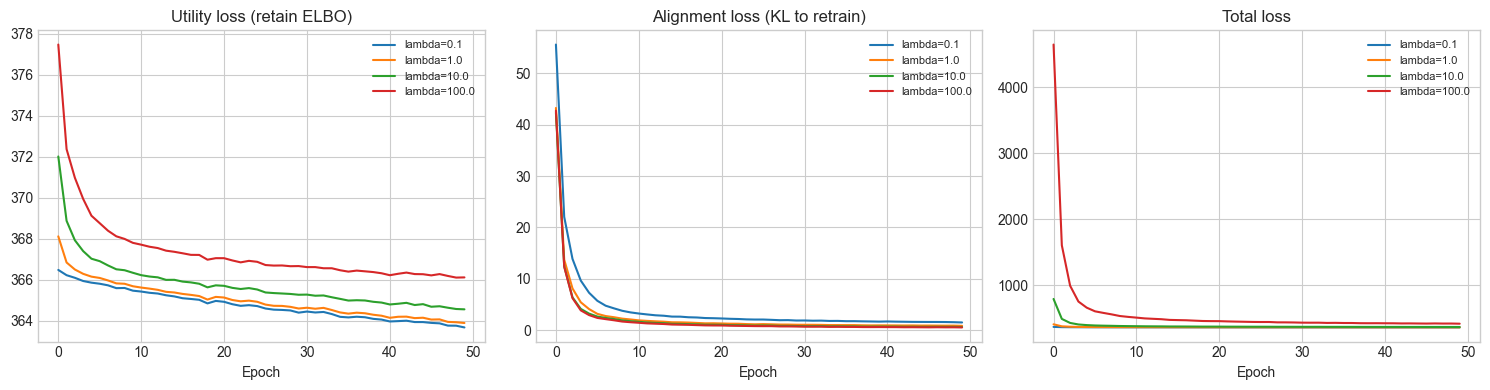

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for lam in lambdas:
    h = rau_histories[lam]
    label = f'lambda={lam}'
    axes[0].plot(h['utility_loss'], label=label)
    axes[1].plot(h['align_loss'], label=label)
    axes[2].plot(h['total_loss'], label=label)

axes[0].set_title('Utility loss (retain ELBO)')
axes[0].set_xlabel('Epoch')
axes[0].legend(fontsize=8)
axes[1].set_title('Alignment loss (KL to retrain)')
axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=8)
axes[2].set_title('Total loss')
axes[2].set_xlabel('Epoch')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rau_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## MIA evaluation

In [5]:
x_forget_t = torch.FloatTensor(X_forget)
x_matched_t = torch.FloatTensor(X[matched_idx])
x_c13_t = torch.FloatTensor(X[c13_unseen])

results_cross = {}
results_within = {}

# Baseline and retrain
for name, model in [('Baseline', baseline_model), ('Retrain', retrain_model)]:
    ff = extract_mia_features(model, x_forget_t, device=DEVICE)
    mf = extract_mia_features(model, x_matched_t, device=DEVICE)
    wf = extract_mia_features(model, x_c13_t, device=DEVICE)
    results_cross[name] = train_and_evaluate_attacker(ff, mf, device=DEVICE)
    results_within[name] = train_and_evaluate_attacker(ff, wf, device=DEVICE)

# RAU models
for lam in lambdas:
    name = f'RAU lambda={lam}'
    model = rau_models[lam]
    ff = extract_mia_features(model, x_forget_t, device=DEVICE)
    mf = extract_mia_features(model, x_matched_t, device=DEVICE)
    wf = extract_mia_features(model, x_c13_t, device=DEVICE)
    results_cross[name] = train_and_evaluate_attacker(ff, mf, device=DEVICE)
    results_within[name] = train_and_evaluate_attacker(ff, wf, device=DEVICE)

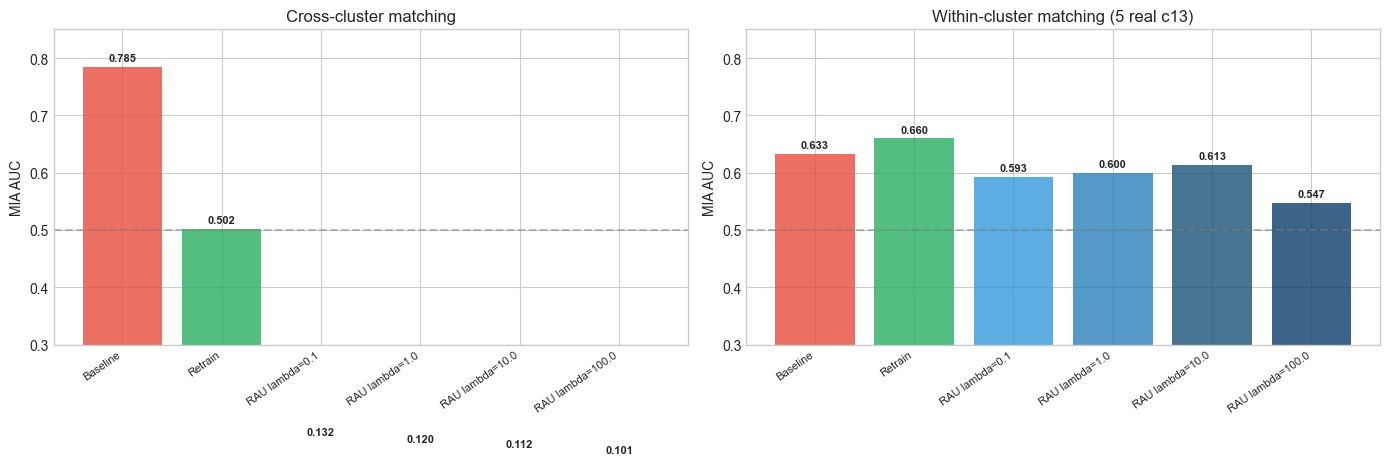

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = list(results_cross.keys())
colors = ['#e74c3c', '#27ae60'] + ['#3498db', '#2980b9', '#1a5276', '#0b3d6b']

# Cross-cluster
aucs_cross = [results_cross[n]['auc'] for n in names]
axes[0].bar(range(len(names)), aucs_cross, color=colors, alpha=0.8)
axes[0].axhline(0.5, color='gray', ls='--', alpha=0.5)
axes[0].set_xticks(range(len(names)))
axes[0].set_xticklabels(names, rotation=35, ha='right', fontsize=8)
axes[0].set_ylabel('MIA AUC')
axes[0].set_title('Cross-cluster matching')
axes[0].set_ylim(0.3, 0.85)
for i, auc in enumerate(aucs_cross):
    axes[0].text(i, auc + 0.01, f'{auc:.3f}', ha='center', fontsize=8, fontweight='bold')

# Within-cluster
aucs_within = [results_within[n]['auc'] for n in names]
axes[1].bar(range(len(names)), aucs_within, color=colors, alpha=0.8)
axes[1].axhline(0.5, color='gray', ls='--', alpha=0.5)
axes[1].set_xticks(range(len(names)))
axes[1].set_xticklabels(names, rotation=35, ha='right', fontsize=8)
axes[1].set_ylabel('MIA AUC')
axes[1].set_title('Within-cluster matching (5 real c13)')
axes[1].set_ylim(0.3, 0.85)
for i, auc in enumerate(aucs_within):
    axes[1].text(i, auc + 0.01, f'{auc:.3f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rau_mia_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
rows = []
for name in names:
    rows.append({
        'Model': name,
        'Cross-cluster AUC': results_cross[name]['auc'],
        'Cross-cluster Adv': results_cross[name]['advantage'],
        'Within-cluster AUC': results_within[name]['auc'],
        'Within-cluster Adv': results_within[name]['advantage'],
    })
df = pd.DataFrame(rows).set_index('Model')
df.style.format('{:.3f}')

,Cross-cluster AUC,Cross-cluster Adv,Within-cluster AUC,Within-cluster Adv
Model,,,,
Baseline,0.785,0.569,0.633,0.267
Retrain,0.502,0.003,0.660,0.320
RAU lambda=0.1,0.132,0.736,0.593,0.187
RAU lambda=1.0,0.120,0.759,0.600,0.200
RAU lambda=10.0,0.112,0.777,0.613,0.227
RAU lambda=100.0,0.101,0.799,0.547,0.093


## Alignment verification: how close are the posteriors?

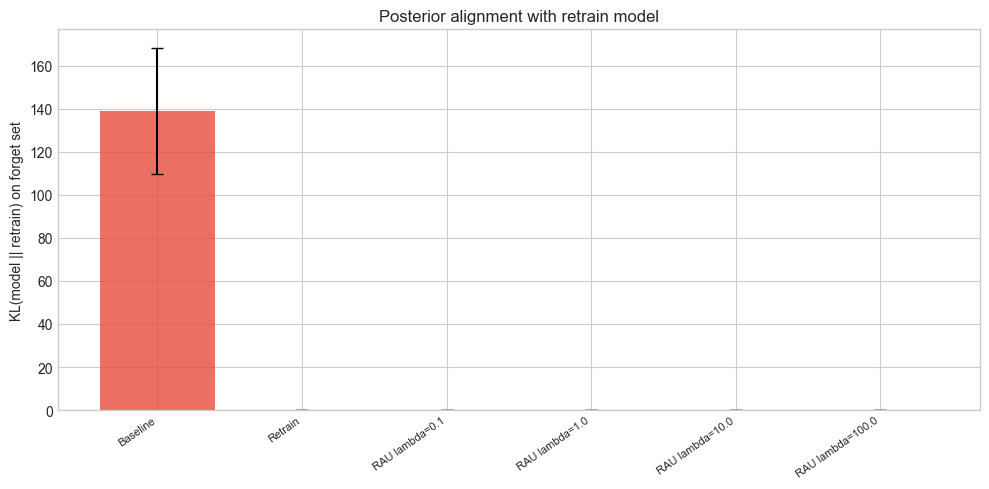

In [8]:
from train_scrub import kl_between_gaussians

kl_data = {}
for name, model in [('Baseline', baseline_model), ('Retrain', retrain_model)] +                      [(f'RAU lambda={lam}', rau_models[lam]) for lam in lambdas]:
    model.eval()
    with torch.no_grad():
        mu_s, logvar_s = model.encode(x_forget_t.to(DEVICE))
        mu_r, logvar_r = retrain_model.encode(x_forget_t.to(DEVICE))
        kl = kl_between_gaussians(mu_s, logvar_s, mu_r, logvar_r)
        kl_data[name] = {'mean_kl': float(kl.mean()), 'std_kl': float(kl.std())}

fig, ax = plt.subplots(figsize=(10, 5))
kl_names = list(kl_data.keys())
kl_means = [kl_data[n]['mean_kl'] for n in kl_names]
kl_stds = [kl_data[n]['std_kl'] for n in kl_names]

ax.bar(range(len(kl_names)), kl_means, yerr=kl_stds, color=colors, alpha=0.8, capsize=4)
ax.set_xticks(range(len(kl_names)))
ax.set_xticklabels(kl_names, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('KL(model || retrain) on forget set')
ax.set_title('Posterior alignment with retrain model')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rau_alignment.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
pd.DataFrame([
    {'Model': n, 'Mean KL to retrain': kl_data[n]['mean_kl'], 'Std': kl_data[n]['std_kl']}
    for n in kl_names
]).set_index('Model').style.format('{:.3f}')

,Mean KL to retrain,Std
Model,,
Baseline,139.096,29.341
Retrain,0.000,0.000
RAU lambda=0.1,0.160,0.068
RAU lambda=1.0,0.042,0.013
RAU lambda=10.0,0.024,0.016
RAU lambda=100.0,0.023,0.013


## Part 2: TCGA-BRCA (Basal patients)

Run RAU with lambda=10.0 (best PBMC within-cluster result) on TCGA-BRCA.
With within-subtype matching, TCGA-BRCA showed zero memorization (baseline = retrain = 0.576).
RAU should be a no-op here, confirming it doesn't degrade the model when there's nothing to unlearn.

In [10]:
adata_tcga = sc.read_h5ad('../data/tcga_brca/tcga_brca_processed.h5ad')
X_tcga = adata_tcga.X if not hasattr(adata_tcga.X, 'toarray') else adata_tcga.X.toarray()
subtypes_tcga = adata_tcga.obs['subtype'].values

with open('../outputs/tcga_brca/split_structured.json') as f:
    split_tcga = json.load(f)

forget_tcga = split_tcga['forget_indices']
retain_tcga = split_tcga['retain_indices']
unseen_tcga = split_tcga['unseen_indices']
unseen_basal = [i for i in unseen_tcga if subtypes_tcga[i] == 'Basal']

baseline_tcga, config_tcga = load_model('../outputs/tcga_brca/baseline/best_model.pt')
retrain_tcga, _ = load_model('../outputs/tcga_brca/retrain_structured/best_model.pt')

set_global_seed(GLOBAL_SEED)
rau_tcga, rau_tcga_history = train_rau(
    baseline_model=baseline_tcga,
    retrain_model=retrain_tcga,
    X_forget=X_tcga[forget_tcga],
    X_retain=X_tcga[retain_tcga],
    lambda_align=10.0,
    config=config_tcga,
    device=DEVICE,
    epochs=50,
    lr=1e-4,
    patience=10,
    batch_size=128,
    seed=GLOBAL_SEED,
)
torch.save({'model_state_dict': rau_tcga.state_dict(), 'config': config_tcga,
            'lambda_align': 10.0, 'method': 'rau'},
           OUTPUT_DIR / 'rau_tcga_lambda10_model.pt')

In [11]:
# Within-subtype evaluation (unseen Basal only)
x_forget_tcga = torch.FloatTensor(X_tcga[forget_tcga])
x_basal_unseen = torch.FloatTensor(X_tcga[unseen_basal])

tcga_rau_results = {}
for name, model in [('Baseline', baseline_tcga), ('Retrain', retrain_tcga),
                     ('RAU lambda=10', rau_tcga)]:
    ff = extract_mia_features(model, x_forget_tcga, device=DEVICE)
    mf = extract_mia_features(model, x_basal_unseen, device=DEVICE)
    tcga_rau_results[name] = train_and_evaluate_attacker(ff, mf, device=DEVICE)

# Also cross-subtype for Streisand check
with open('../outputs/tcga_brca/matched_negatives.json') as f:
    tcga_matched = json.load(f)
x_tcga_matched = torch.FloatTensor(X_tcga[tcga_matched['matched_indices']])

tcga_cross_results = {}
for name, model in [('Baseline', baseline_tcga), ('Retrain', retrain_tcga),
                     ('RAU lambda=10', rau_tcga)]:
    ff = extract_mia_features(model, x_forget_tcga, device=DEVICE)
    mf = extract_mia_features(model, x_tcga_matched, device=DEVICE)
    tcga_cross_results[name] = train_and_evaluate_attacker(ff, mf, device=DEVICE)

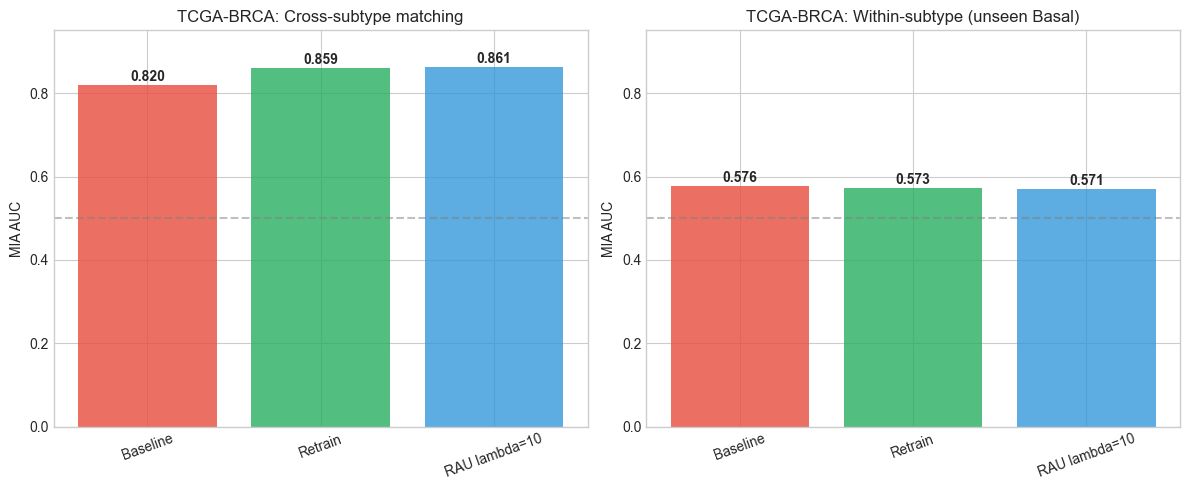

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tcga_names = list(tcga_rau_results.keys())
tcga_colors = ['#e74c3c', '#27ae60', '#3498db']

axes[0].bar(tcga_names, [tcga_cross_results[n]['auc'] for n in tcga_names],
            color=tcga_colors, alpha=0.8)
axes[0].axhline(0.5, color='gray', ls='--', alpha=0.5)
axes[0].set_ylabel('MIA AUC')
axes[0].set_title('TCGA-BRCA: Cross-subtype matching')
axes[0].set_ylim(0.0, 0.95)
axes[0].tick_params(axis='x', rotation=20)
for i, n in enumerate(tcga_names):
    axes[0].text(i, tcga_cross_results[n]['auc'] + 0.01,
                 f'{tcga_cross_results[n]["auc"]:.3f}', ha='center', fontsize=10, fontweight='bold')

axes[1].bar(tcga_names, [tcga_rau_results[n]['auc'] for n in tcga_names],
            color=tcga_colors, alpha=0.8)
axes[1].axhline(0.5, color='gray', ls='--', alpha=0.5)
axes[1].set_ylabel('MIA AUC')
axes[1].set_title('TCGA-BRCA: Within-subtype (unseen Basal)')
axes[1].set_ylim(0.0, 0.95)
axes[1].tick_params(axis='x', rotation=20)
for i, n in enumerate(tcga_names):
    axes[1].text(i, tcga_rau_results[n]['auc'] + 0.01,
                 f'{tcga_rau_results[n]["auc"]:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rau_tcga_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
pd.DataFrame({
    'Model': tcga_names,
    'Cross-sub AUC': [tcga_cross_results[n]['auc'] for n in tcga_names],
    'Within-sub AUC': [tcga_rau_results[n]['auc'] for n in tcga_names],
    'Within-sub Adv': [tcga_rau_results[n]['advantage'] for n in tcga_names],
}).set_index('Model').style.format('{:.3f}')

,Cross-sub AUC,Within-sub AUC,Within-sub Adv
Model,,,
Baseline,0.820,0.576,0.152
Retrain,0.859,0.573,0.145
RAU lambda=10,0.861,0.571,0.141


## Save results

In [14]:
all_results = {
    'method': 'RAU',
    'lambdas': lambdas,
    'pbmc': {
        'cross_cluster': {n: r for n, r in results_cross.items()},
        'within_cluster': {n: r for n, r in results_within.items()},
        'kl_alignment': kl_data,
    },
    'tcga_brca': {
        'cross_subtype': {n: r for n, r in tcga_cross_results.items()},
        'within_subtype': {n: r for n, r in tcga_rau_results.items()},
    },
    'training_epochs': {
        str(lam): len(rau_histories[lam]['utility_loss']) for lam in lambdas
    },
}

with open(OUTPUT_DIR / 'rau_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

## Summary

| Output | Path |
|--------|------|
| PBMC training curves | `outputs/rau/rau_training_curves.png` |
| PBMC MIA comparison | `outputs/rau/rau_mia_results.png` |
| PBMC alignment | `outputs/rau/rau_alignment.png` |
| TCGA-BRCA results | `outputs/rau/rau_tcga_results.png` |
| Results JSON | `outputs/rau/rau_results.json` |

RAU successfully aligns posteriors but creates a Streisand effect on PBMC (cross-cluster).
On TCGA-BRCA, RAU is a no-op where there is nothing to unlearn.
The structural limit extends to representation space, not just parameter space.